Imports

In [1]:

import numpy as np
import matplotlib.pyplot as plt

from Background_functions import read_audio_file, split_audio_segments, start_end_times
from STFT import resample_audio, stft_calculation, plot_spectrogram
from DFT import dp

from pathlib import Path
from scipy.spatial import distance as dist

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\DataSubmission\2023_04_22")

Data download

In [2]:
audio = DATA_22 / "20230422_171301.WAV"
f_s, x = read_audio_file(audio)
duration = len(x) / f_s  # Duration of the audio in seconds

start = 0.0  # Start time in seconds
window = 3.0  # Window length in seconds
start_t = []
end_t = []

while start < duration:
    end = min(start + window, duration)  # Ensure we don't exceed the audio duration
    start_t.append(start)
    end_t.append(end)
    start += window  # Move to the next window
length = len(start_t)
print(length)

audio_segments = split_audio_segments(x, f_s, start_t, end_t)

89479


Template

In [3]:
text = DATA_22 / "20230422_171301.Detections.selections.txt"
temp_marks, start_t_temp, end_t_temp = start_end_times(text)

whale_call_segments = split_audio_segments(x, f_s, start_t_temp, end_t_temp)
print(len(whale_call_segments))
audio_template_1 = whale_call_segments[0]

628


In [4]:
def z_normalize_frames(seq):
    # seq shape: (n_time_frames, n_freq_bins)
    mean = seq.mean(axis=1, keepdims=True)
    std = seq.std(axis=1, keepdims=True) + 1e-8
    return (seq - mean) / std

DTW Model

In [5]:
def DTW_calc(template_Zxx, comparison_Zxx):
    x_seq = np.abs(template_Zxx).T      # shape: (n_time_frames, n_freq_bins)
    y_seq = np.abs(comparison_Zxx).T    # shape: (n_time_frames, n_freq_bins)

    dist_mat = dist.cdist(x_seq, y_seq, "cosine")
    path, cost_mat = dp(dist_mat)
    ali_cost = cost_mat[-1, -1]
    #print("Alignment cost: {:.4f}".format(ali_cost))

    M = x_seq.shape[0]
    N = y_seq.shape[0]
    norm_ali_cost = ali_cost / (M + N)
    #print("Normalized alignment cost: {:.4f}".format(norm_ali_cost))
    return norm_ali_cost

STFT Model

In [6]:
def short_time_calc(sig, fs):
    fs_new = 2000
    resampled_sig = resample_audio(sig, fs, fs_new)
    f_seg, t_seg, Zxx_seg = stft_calculation(resampled_sig, fs, fs_new)
    #plot_spectrogram(f_seg, t_seg, Zxx_seg, fs_new)
    return f_seg, t_seg, Zxx_seg, fs_new

Running loop for STFT template analysis

In [13]:
stft_cost = []
oor = []
for i in range(628):
    audio_seg = whale_call_segments[i]
    f_temp, t_temp, Zxx_temp, fs_new = short_time_calc(audio_template_1, f_s)
    f_seg, t_seg, Zxx_seg, fs_new = short_time_calc(audio_seg, f_s)
    dtw_cost = DTW_calc(Zxx_temp, Zxx_seg)
    stft_cost.append(dtw_cost)
    if 0.0 < dtw_cost < 0.1:
        oor.append(i)
    
    #print(i)
avg_cost = np.mean(stft_cost)
max_cost = np.max(stft_cost)
min_cost = np.min(stft_cost)
print(f"avg_cost: {avg_cost:.2f}")
print(f"max_cost: {max_cost:.2f}")
print(f"min_cost: {min_cost:.2f}")
print(oor)

avg_cost: 0.12
max_cost: 0.55
min_cost: 0.00
[0, 1, 3, 4, 5, 6, 7, 10, 11, 14, 16, 17, 20, 21, 23, 24, 25, 26, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 48, 49, 51, 52, 57, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 77, 78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 94, 95, 96, 97, 98, 100, 101, 103, 104, 105, 106, 107, 109, 110, 111, 112, 113, 114, 115, 117, 118, 119, 120, 121, 122, 123, 126, 128, 129, 132, 133, 134, 135, 136, 137, 139, 140, 141, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 161, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 184, 185, 186, 189, 190, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 203, 205, 206, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 222, 223, 224, 225, 226, 227, 228, 229, 230, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 247, 250, 255, 256, 257, 258, 259, 

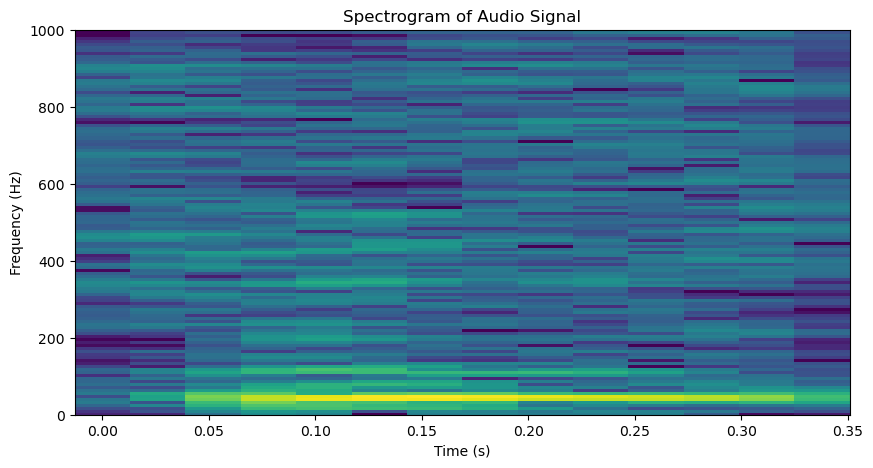

445


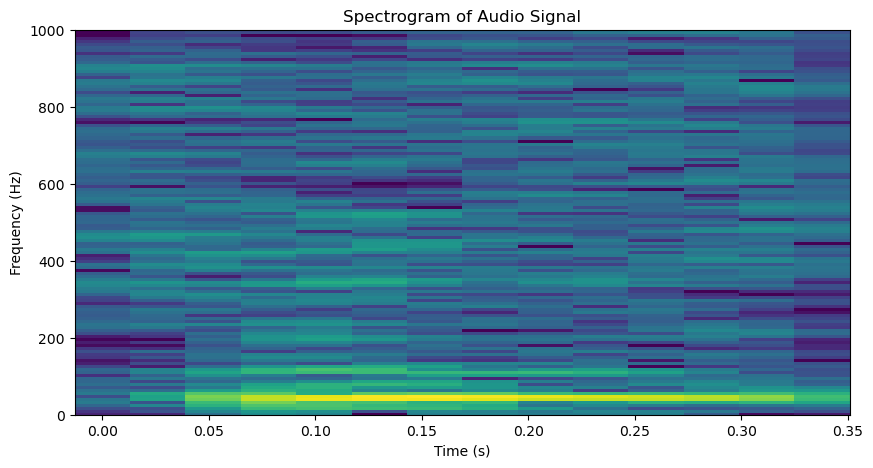

1.1895246692412391e-17
0
0
51713.5319375


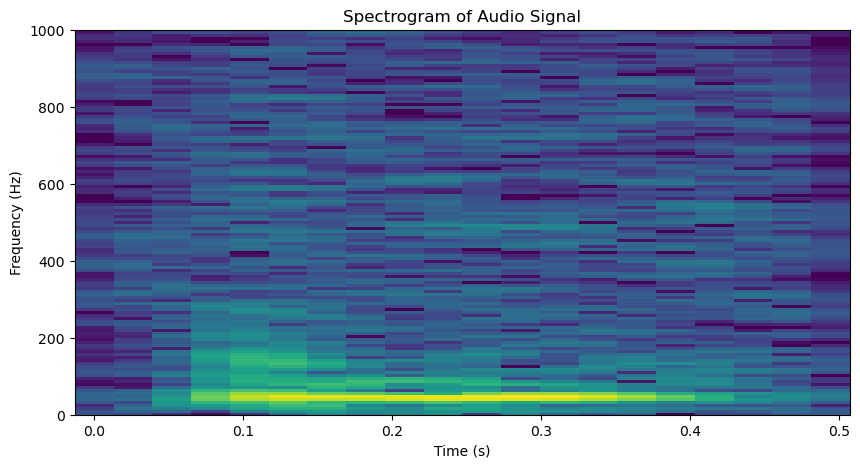

0.050896549242899415
1
1
68032.2519375


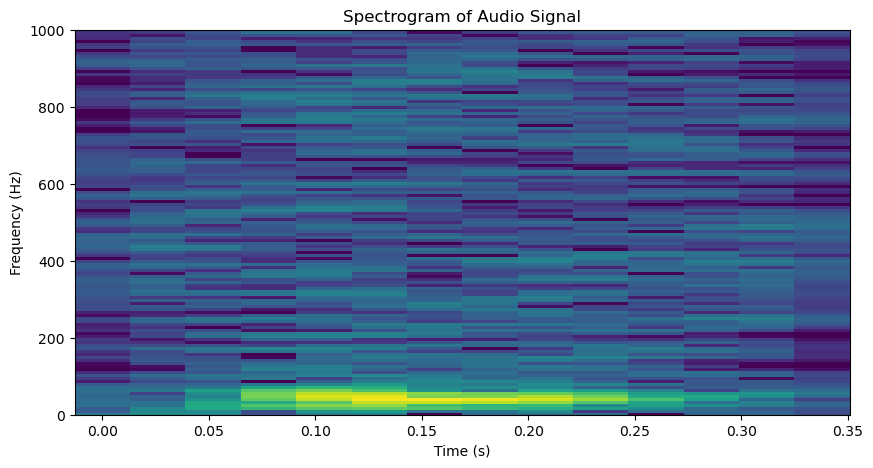

0.09938749278721226
2
3
68132.1239375


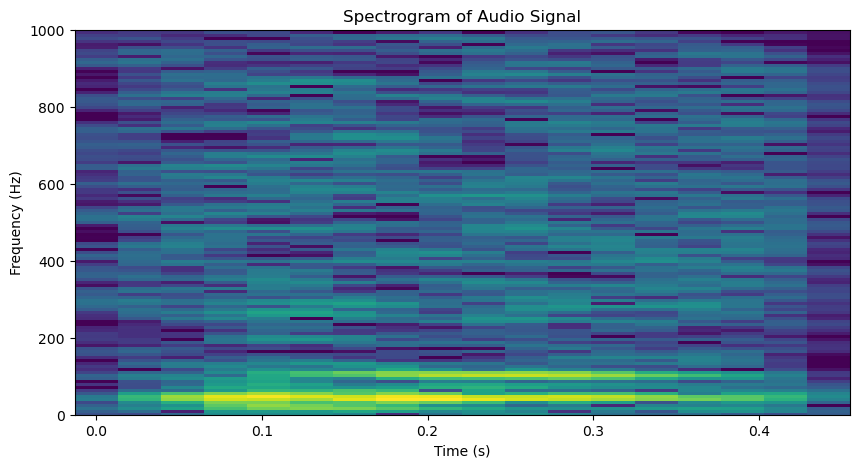

0.07126268169839471
3
4
75273.49993749999


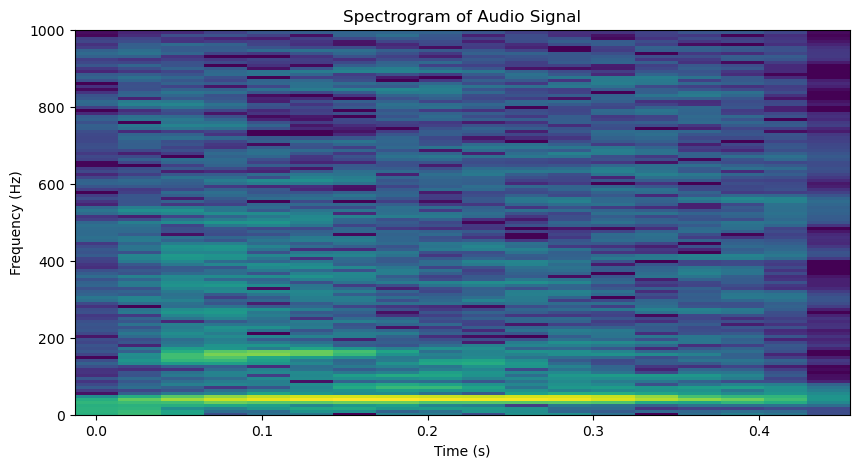

0.07251433784619106
4
5
75495.41993749999


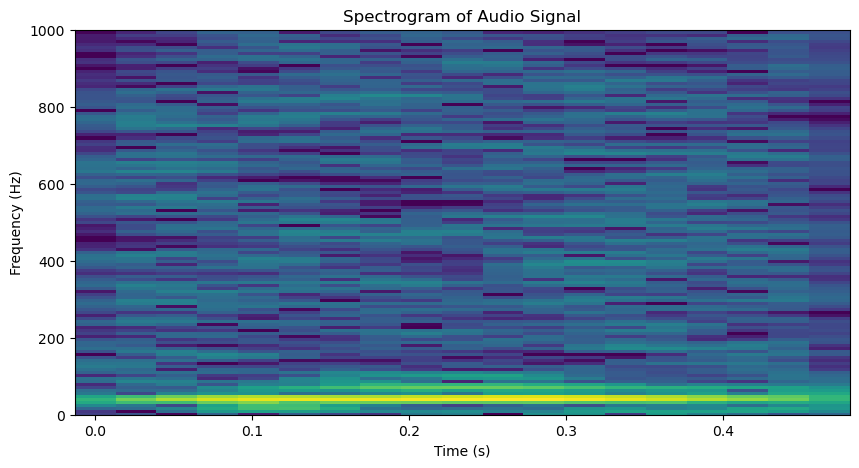

0.06111904842850892
5
6
76653.0199375


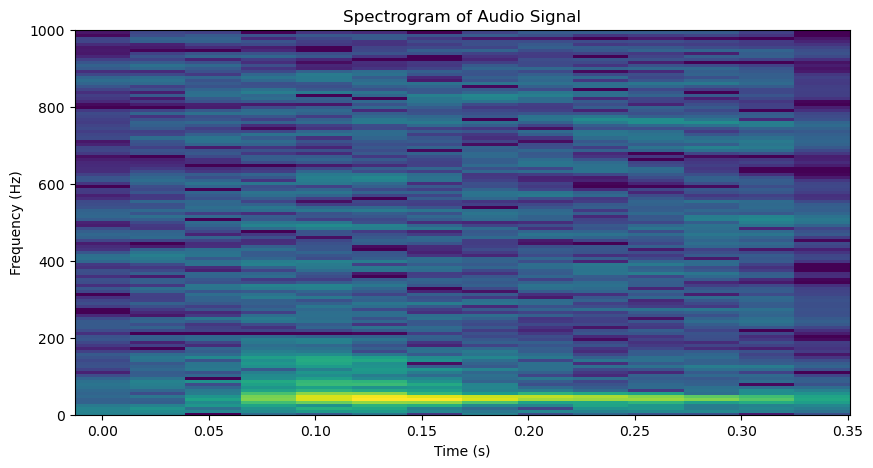

0.049185527809931226
6
7
130687.06793749999


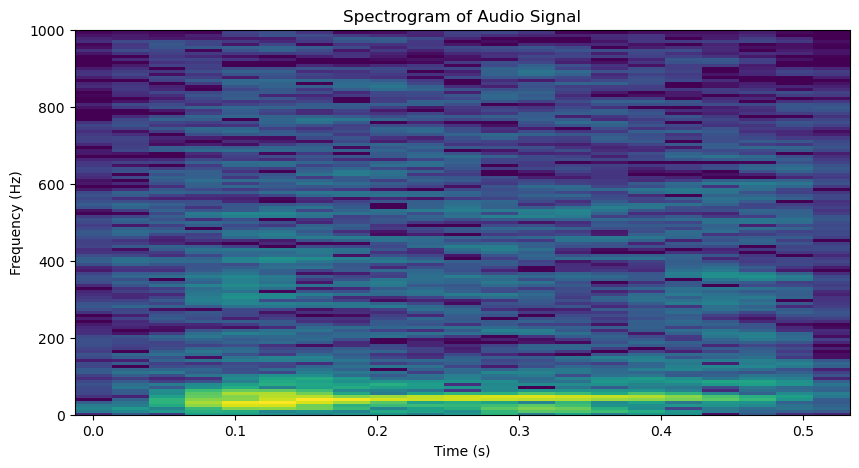

0.0808262662696362
7
10
134325.9479375


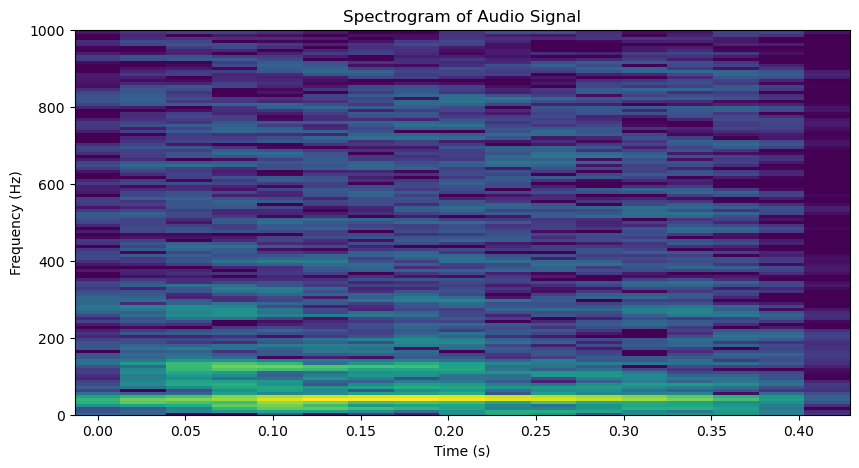

0.08187838466453354
8
11
134626.1079375


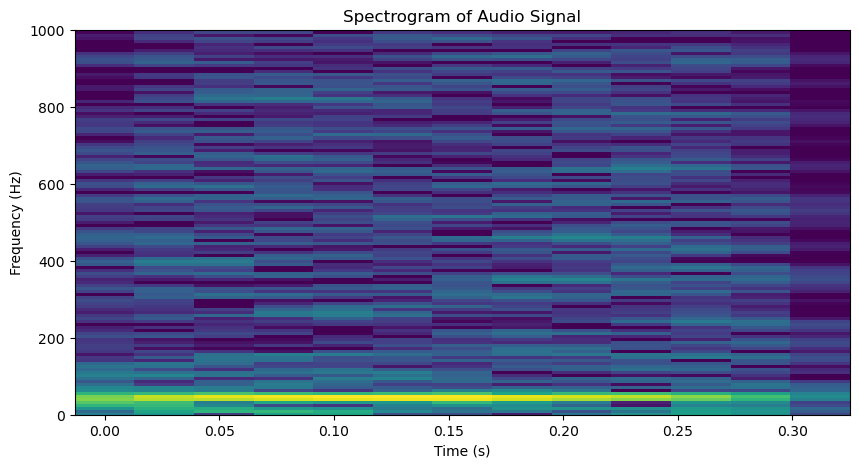

0.06325202623286288
9
14
134912.18793749998


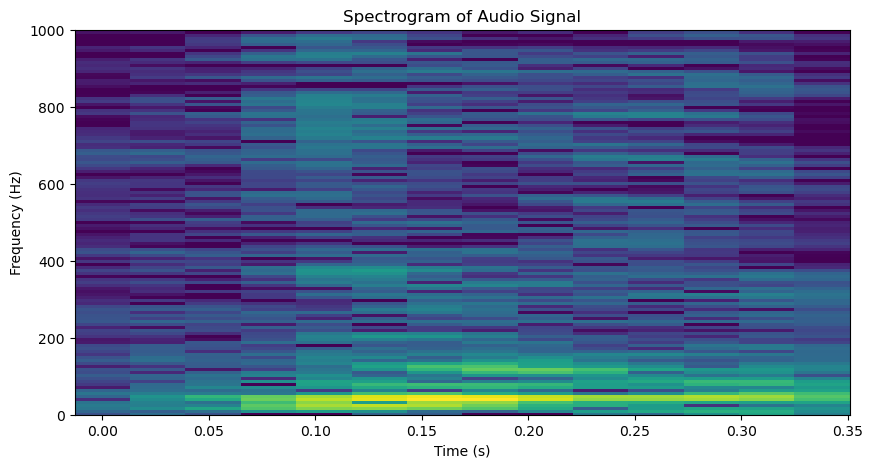

0.06412874731386828
10
16
138483.7719375


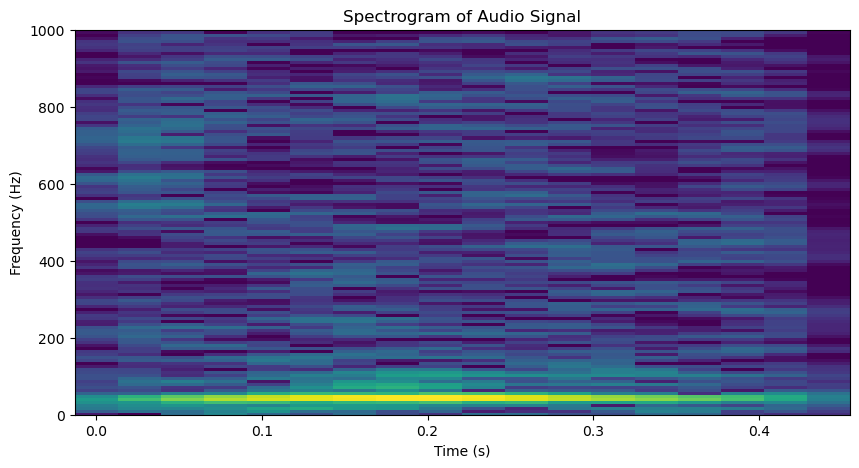

0.045201121782335596
11
17
143045.0839375


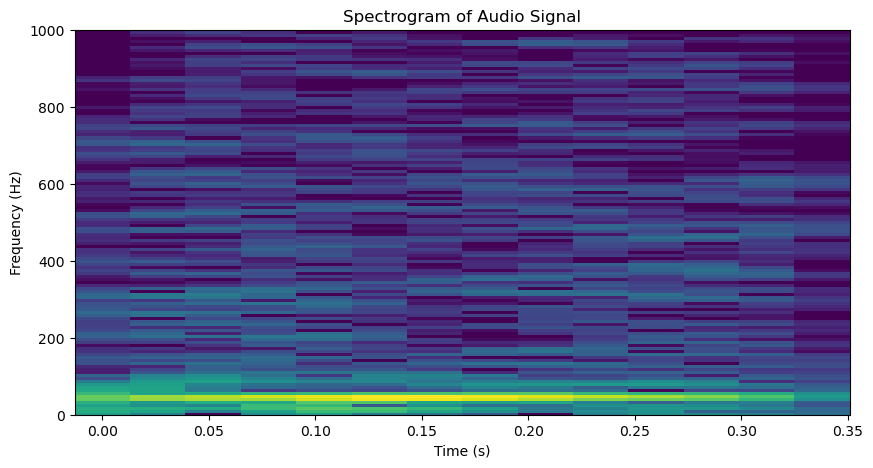

0.06157867541310967
12
20
146669.2119375


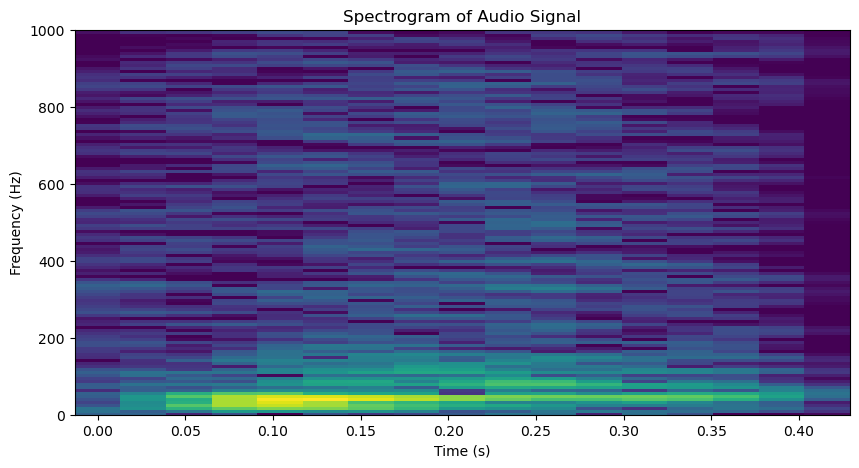

0.06694114931656638
13
21
146754.2679375


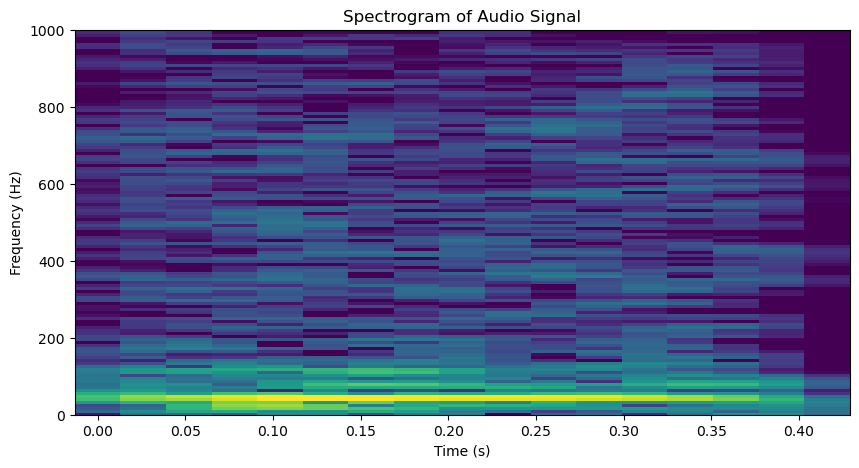

0.06197864697456406
14
23
146870.3959375


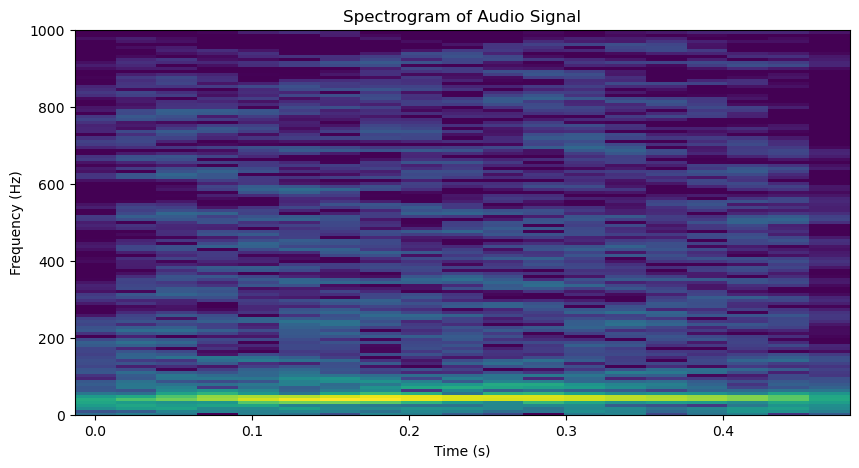

0.0526853487218127
15
24
147054.9079375


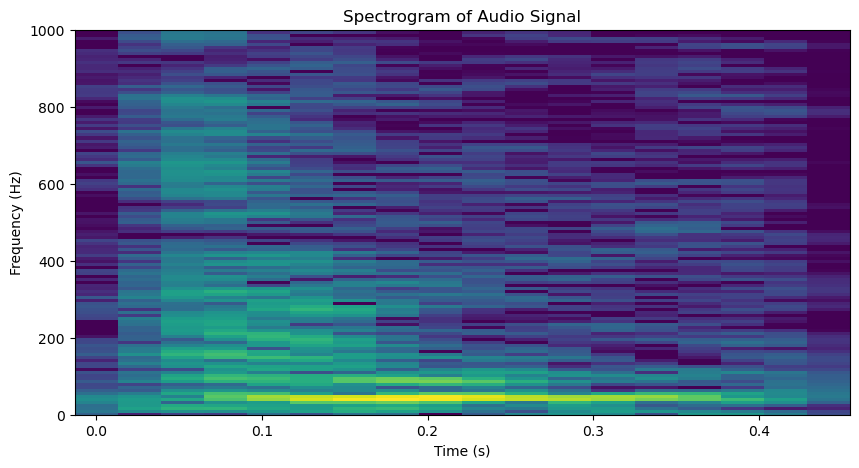

0.07629897432239119
16
25
147081.9479375


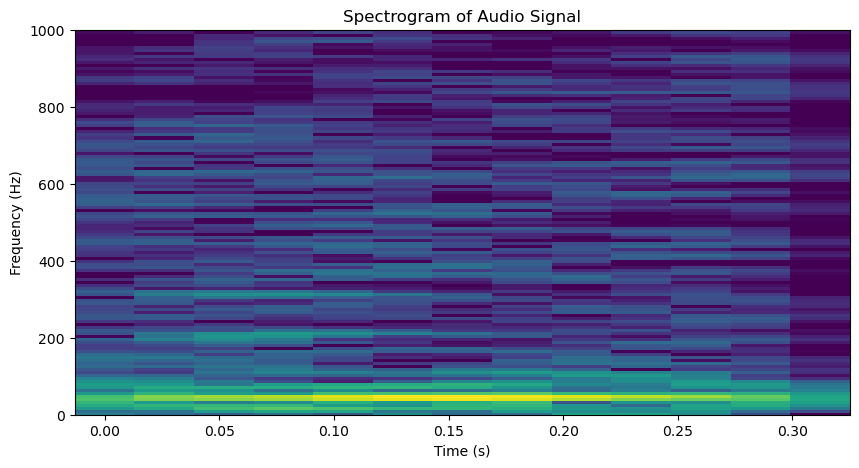

0.05722775421189714
17
26
147145.46793749998


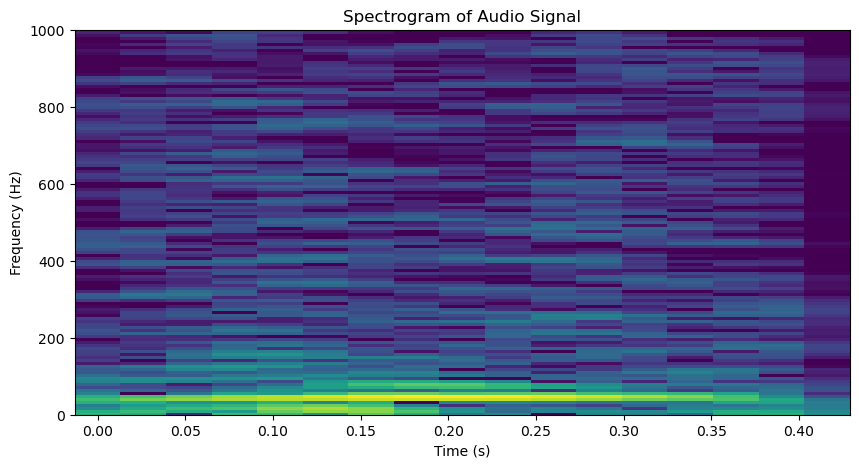

0.09131773053005912
18
28
147218.2999375


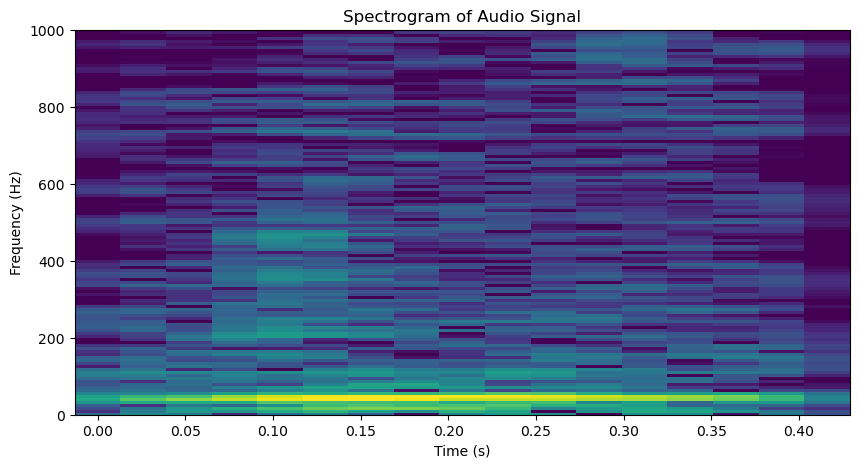

0.0523354626910031
19
29
147440.89193749998


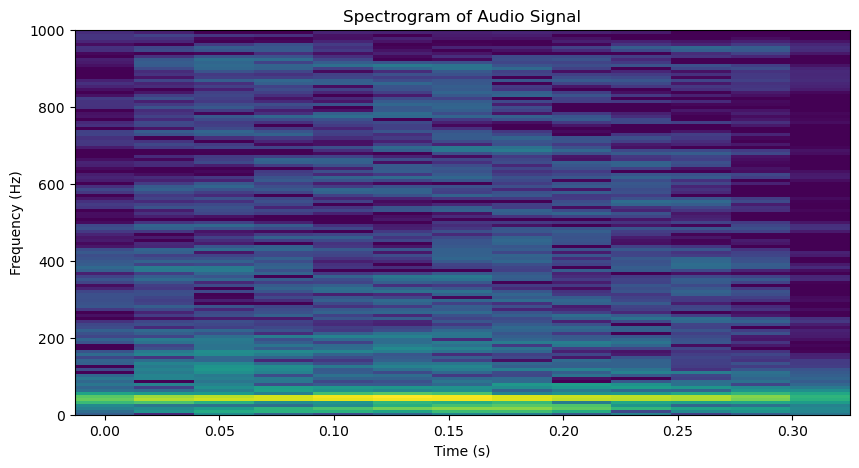

0.06235728052669177
20
30
147593.46793749998


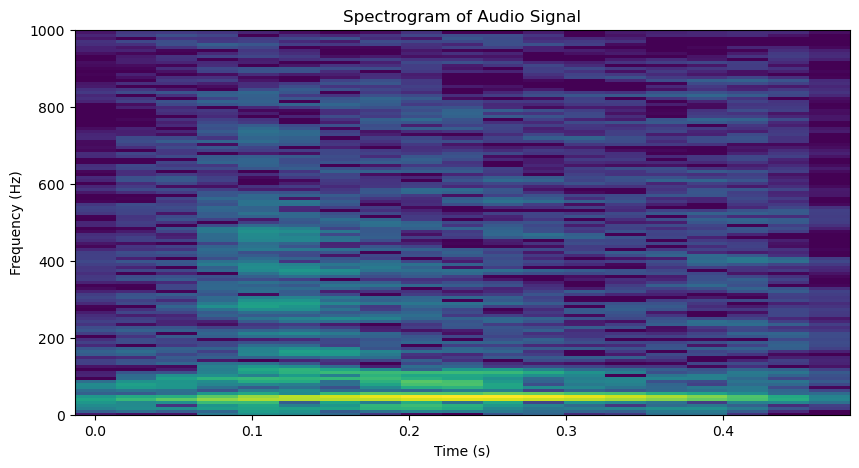

0.05564695372825944
21
31
147663.4839375


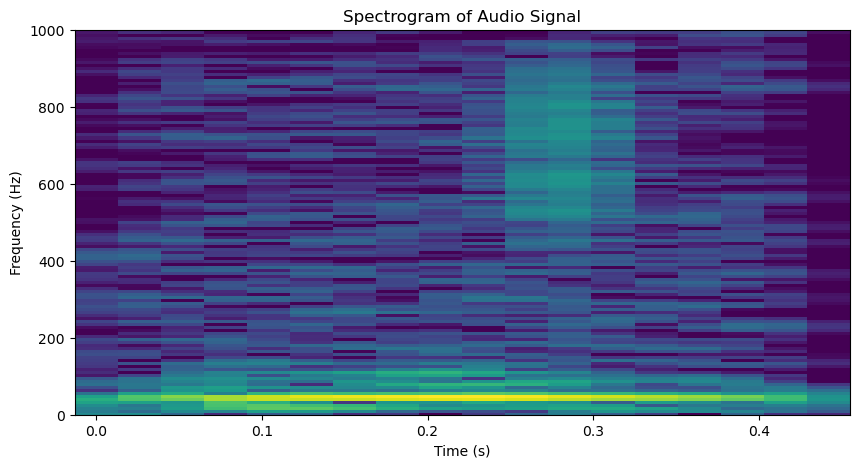

0.04585508289341375
22
32
147720.7959375


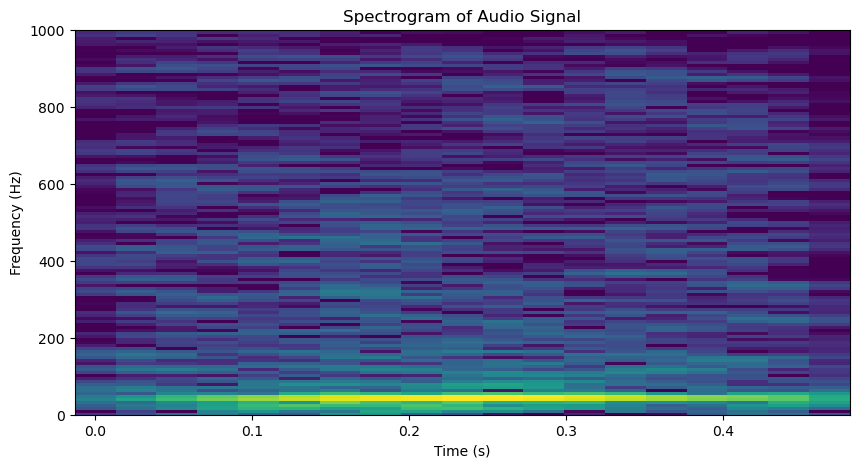

0.03803915939747969
23
34
148103.32393749998


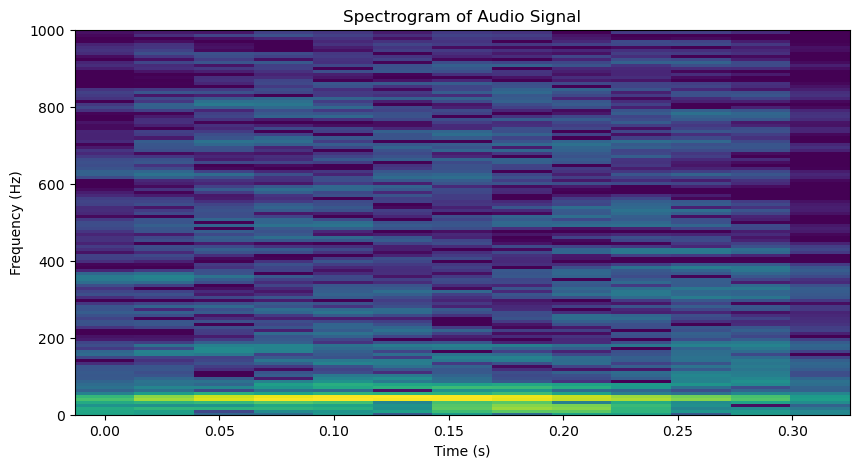

0.07529770313065366
24
35
150208.31593749998


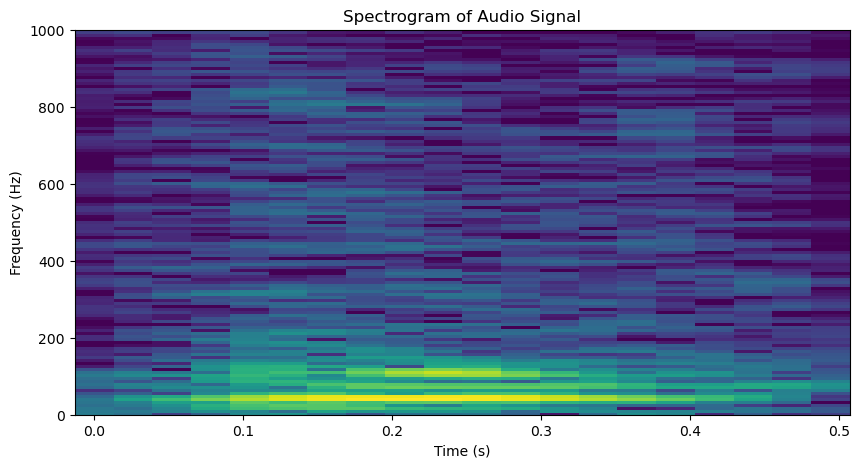

0.09225919794608463
25
36
150403.9959375


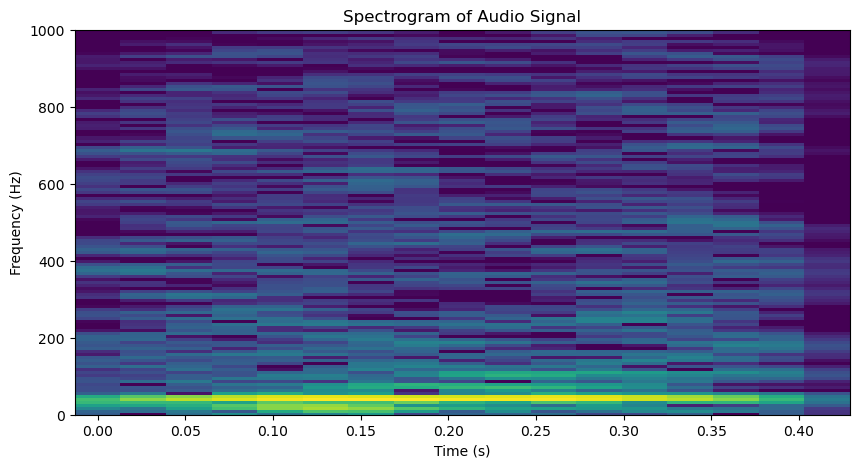

0.06481653024692836
26
37
150458.2359375


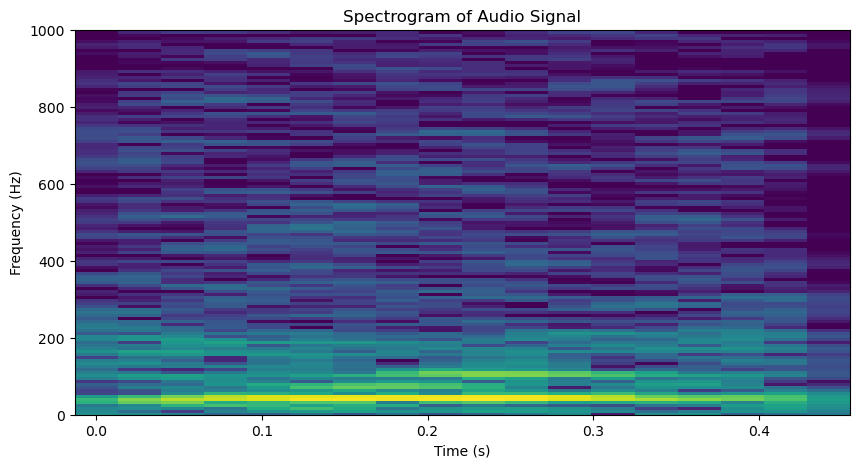

0.07128946656458113
27
38
150481.9159375


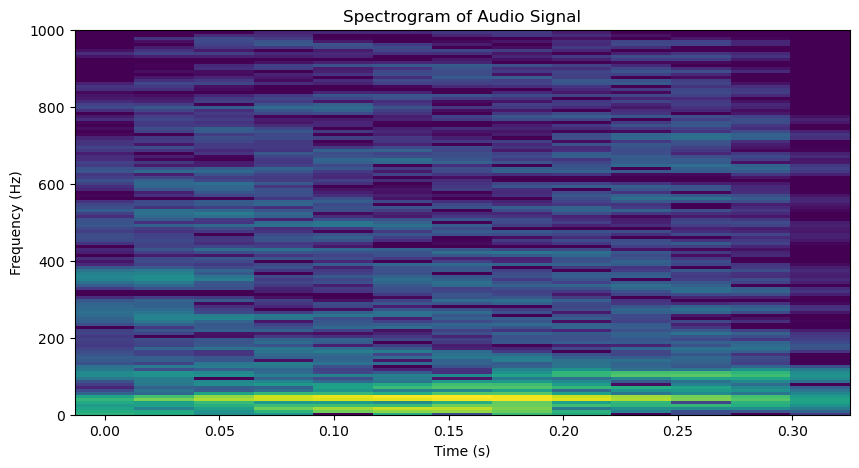

0.08613399083993302
28
39
150513.4999375


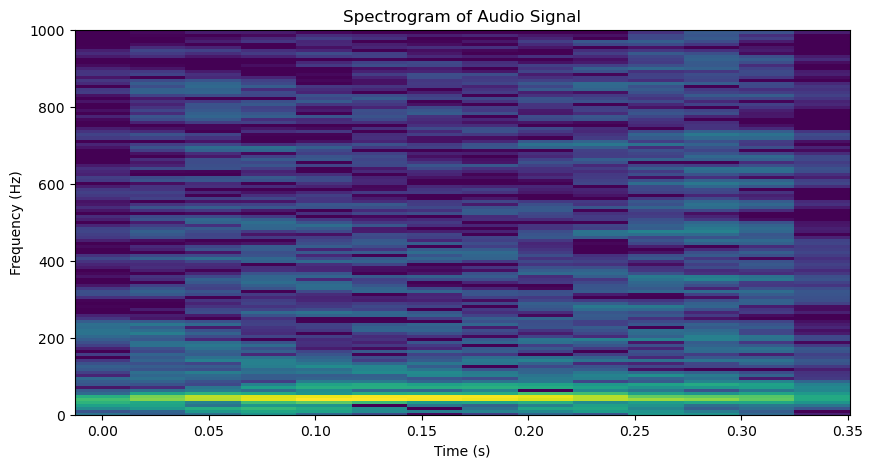

0.057210318560850466
29
40
150753.5319375


In [14]:
plot_spectrogram(f_temp, t_temp, Zxx_temp, fs_new)
print(len(oor))
for j in range(30):
    f_sig, t_sig, Zxx_sig, fs_new = short_time_calc(whale_call_segments[oor[j]], f_s)
    plot_spectrogram(f_sig, t_sig, Zxx_sig, fs_new)
    plt.show()
    dtw_cost = DTW_calc(Zxx_temp, Zxx_sig)
    print(dtw_cost)
    print(j)
    print(oor[j])
    print(start_t_temp[oor[j]])


Running loop for comparison

In [ ]:
stft_cost = []
for i in range(100):
    audio_seg = audio_segments[i]
    f_temp, t_temp, Zxx_temp, fs_new = short_time_calc(audio_template_1, f_s)
    f_seg, t_seg, Zxx_seg, fs_new = short_time_calc(audio_seg, f_s)
    stft_cost.append(DTW_calc(Zxx_temp, Zxx_seg))
    #print(i)
